In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
import xgboost as xgb
from sklearn.metrics import (
    auc,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

# DATA ACQUISITION

In [109]:
# dataset path definition
dataset_path = "../data/raw/capture20110815-2.csv"

In [110]:
print("--- Dataset loading... ---")

# load dataset
df = pd.read_csv(dataset_path)

print("--- Dataset loaded ---")

# number of rows and columns
print(f"Dimension of dataset: {df.shape}")

# dataset info
df.info()

--- Dataset loading... ---
--- Dataset loaded ---
Dimension of dataset: (129832, 15)
<class 'pandas.DataFrame'>
RangeIndex: 129832 entries, 0 to 129831
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   StartTime  129832 non-null  str    
 1   Dur        129832 non-null  float64
 2   Proto      129832 non-null  str    
 3   SrcAddr    129832 non-null  str    
 4   Sport      129035 non-null  str    
 5   Dir        129832 non-null  str    
 6   DstAddr    129832 non-null  str    
 7   Dport      129455 non-null  str    
 8   State      129832 non-null  str    
 9   sTos       128974 non-null  float64
 10  dTos       122936 non-null  float64
 11  TotPkts    129832 non-null  int64  
 12  TotBytes   129832 non-null  int64  
 13  SrcBytes   129832 non-null  int64  
 14  Label      129832 non-null  str    
dtypes: float64(3), int64(3), str(9)
memory usage: 14.9 MB


In [111]:
print("--- Dataset types ---")
print(df.dtypes)

print("--- Verify correct load ---")
df.head(5)

--- Dataset types ---
StartTime        str
Dur          float64
Proto            str
SrcAddr          str
Sport            str
Dir              str
DstAddr          str
Dport            str
State            str
sTos         float64
dTos         float64
TotPkts        int64
TotBytes       int64
SrcBytes       int64
Label            str
dtype: object
--- Verify correct load ---


,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/15 16:43:28.078942,0.000000,tcp,114.33.245.44,6881,?>,147.32.84.118,1567,RA_,0.0,0.0,1,60,60,flow=Background
1,2011/08/15 16:43:32.283576,13.431962,tcp,212.93.105.52,49237,->,147.32.84.229,80,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
2,2011/08/15 16:43:32.456441,13.350228,tcp,212.93.105.52,14906,->,147.32.84.229,13363,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
3,2011/08/15 16:43:32.850648,13.010090,tcp,212.93.105.52,60349,->,147.32.84.229,443,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
4,2011/08/15 16:45:09.305002,20.990047,tcp,115.127.24.116,3198,->,147.32.84.229,443,SR_SA,0.0,0.0,5,308,122,flow=Background-TCP-Established


# DATA TRASFORMATION

In [112]:
#target mapping
df['Target'] = (df['Label'].astype(str).str.contains('Botnet', case=False, regex=False)).astype(int)

# DATA EXPLORATION

Distribuition after binary mapping (Target):
Class 0 (Normal/Background): 128,931 (99.31%)
Class 1 (Botnet): 901 (0.69%)


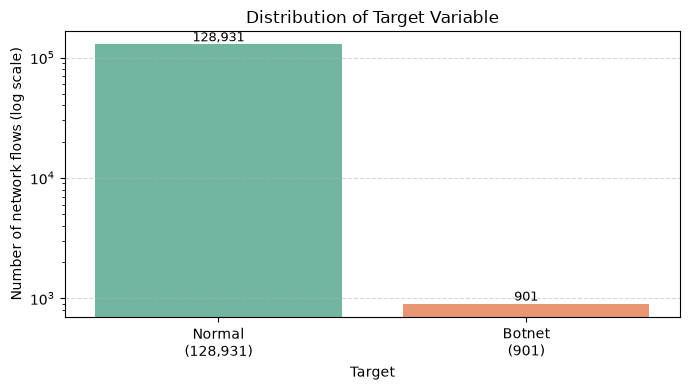

In [113]:
target_counts = df['Target'].value_counts()
target_props = df['Target'].value_counts(normalize=True) * 100

print ("Distribuition after binary mapping (Target):")
print(f"Class 0 (Normal/Background): {target_counts.get(0, 0):,} ({target_props.get(0, 0):.2f}%)")
print(f"Class 1 (Botnet): {target_counts.get(1, 0):,} ({target_props.get(1, 0):.2f}%)")

#visualization unbalanced dataset
plt.figure(figsize=(7, 4))
ax = sns.countplot(
    x='Target', hue='Target', data=df, palette='Set2', legend=False
)

#logarithmic scale
ax.set_yscale('log')
plt.title('Distribution of Target Variable', fontsize=12)
plt.ylabel('Number of network flows (log scale)')
plt.xticks(
    [0, 1],
    [
        f"Normal\n({target_counts.get(0, 0):,})",
        f"Botnet\n({target_counts.get(1, 0):,})",
    ],
)

#numerical annotation on top of bars
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f'{int(height):,}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 0), #text offset
        textcoords='offset points',
        fontsize=9,
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

#set layout to avoid overlapping
plt.tight_layout()
plt.show()


--- Comparative dscriptive statistics ---
Target                      0              1
Dur      median  7.190000e-04       1.592649
         mean    7.793546e+01       6.489200
         std     2.831898e+02      43.092420
         max     1.805828e+03    1139.728638
TotPkts  median  2.000000e+00       6.000000
         mean    3.451280e+01      34.819090
         std     2.502953e+03      78.786008
         max     6.945530e+05     678.000000
TotBytes median  2.640000e+02     366.000000
         mean    2.887931e+04   22660.564928
         std     2.973097e+06   71775.636447
         max     8.537041e+08  615599.000000
SrcBytes median  8.100000e+01     186.000000
         mean    5.040658e+03   10965.527192
         std     5.197573e+05   49864.479033
         max     1.365468e+08  600198.000000


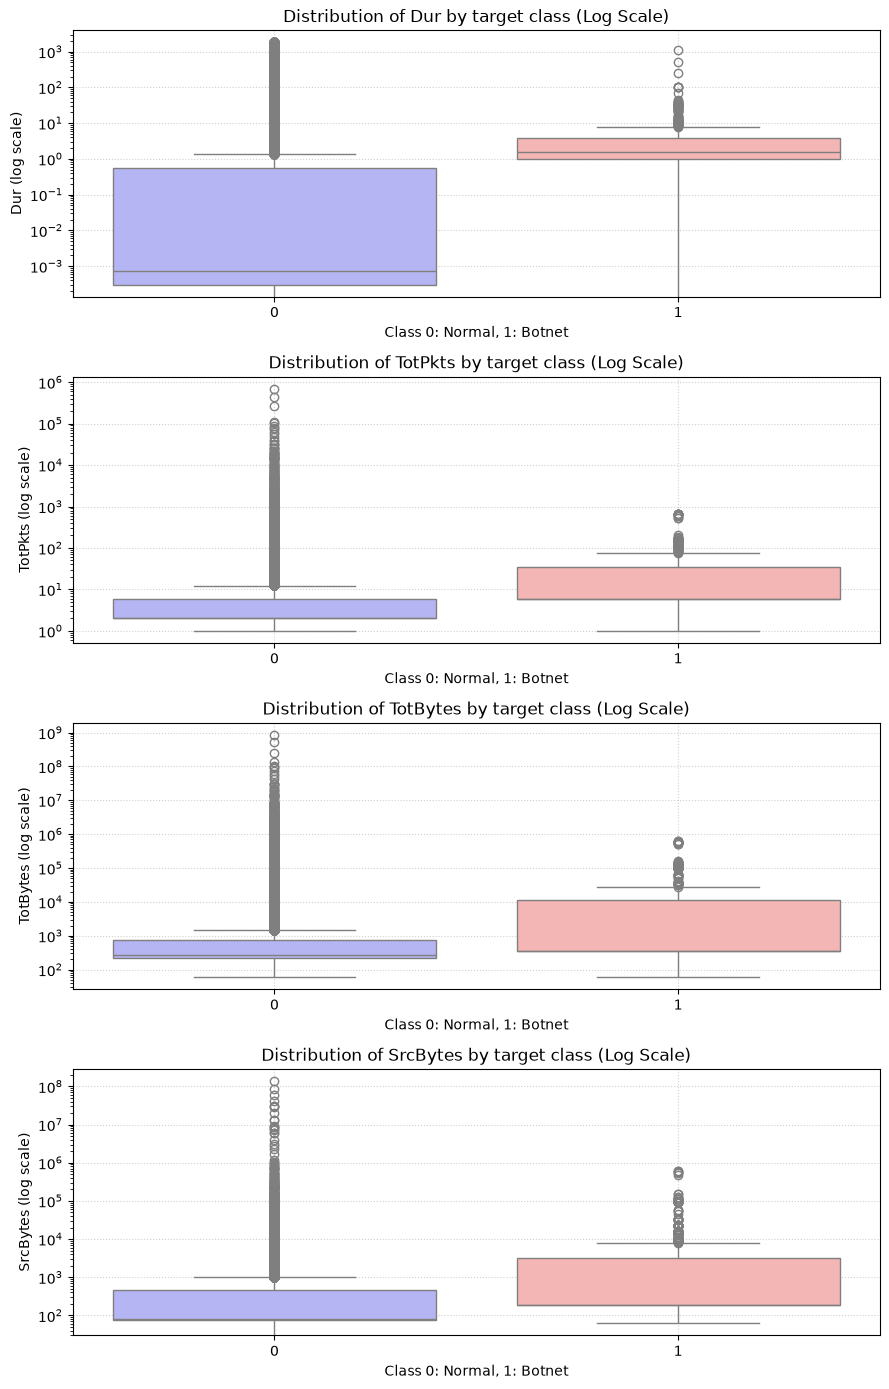


--- Categorical features check ---
Feature 'Proto': 11 unique values
Feature 'State': 155 unique values
Feature 'Sport': 44650 unique values
Feature 'Dport': 12100 unique values


In [ ]:
numerical_features = ['Dur', 'TotPkts', 'TotBytes', 'SrcBytes']

#numerical features conversion, coerce to Nan if conversion fails
for col in numerical_features:
  df[col] = pd.to_numeric(df[col], errors='coerce')

if numerical_features:
  #descriptive statistics confrontation by target class
  print("\n--- Comparative dscriptive statistics ---")
  comparative_stats = df.groupby('Target')[numerical_features].agg(['median', 'mean', 'std', 'max'])
  print(comparative_stats.T)

  #numerical features distribution visualization by target
  num_cols = len(numerical_features)

  #plotting boxplots
  fig, axes = plt.subplots(num_cols, 1, figsize=(9, 3.5 * num_cols))

  for ax, col in zip(axes, numerical_features):
    #boxplot su scala logaritmica per evidenziare la differenza di distribuzione
    sns.boxplot(data=df, x='Target', y=col, hue='Target', palette='bwr', ax=ax,legend=False)
    ax.set_yscale('log')
    ax.set_title(f'Distribution of {col} by target class (Log Scale)')
    ax.set_xlabel('Class 0: Normal, 1: Botnet')
    ax.set_ylabel(f'{col} (log scale)')
    ax.grid(True, linestyle=':', alpha=0.6)

  #set layout to avoid overlapping
  plt.tight_layout()
  plt.show()

#categorical features check
categorical_features = ['Proto', 'State', 'Sport', 'Dport']
if categorical_features:
  print("\n--- Categorical features check ---")
  for col in categorical_features:
    number_unique = df[col].nunique()
    print(f"Feature '{col}': {number_unique} unique values")

# DATA PREPROCESSING

In [115]:
# extraction temporal features
if 'StartTime' in df.columns:
    #conversion of StartTime to datetime, coerce errors to NaT
    df['StartTime'] = pd.to_datetime(df['StartTime'], errors='coerce')
    df['Hour'] = df['StartTime'].dt.hour
    df['DayOfWeek'] = df['StartTime'].dt.dayofweek
    df = df.drop(columns=['StartTime'])

#remove empty extra spaces
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

#remove columns probably data leakage
cols_to_drop = ['Label', 'Target', 'Dir', 'SrcAddr', 'DstAddr']

#definition of X: features, y: target
X = df.drop(columns=cols_to_drop)
y = df['Target']

print(f"Selected numerical features: {numerical_features}")
print(f"Selected categorical features: {categorical_features}")

#pipeline preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)) #activate sparse matrix for memory efficiency
])

#union transformers in a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' #remove columns not specified
)

print("Preprocessing pipeline created successfully.")

Selected numerical features: ['Dur', 'TotPkts', 'TotBytes', 'SrcBytes']
Selected categorical features: ['Proto', 'State', 'Sport', 'Dport']
Preprocessing pipeline created successfully.


# DATA MINING

In [116]:
#RANDOM FOREST cost sensitive learning
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', #major weight to minority class
        random_state=42, 
        n_jobs=-1
    ))
])

#LOGISTIC REGRESSION
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, #maximum iterations for convergence
        random_state=42
    ))
])

#XGBOOST
scale_weight = (y == 0).sum() / (y == 1).sum()

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        scale_pos_weight=scale_weight, #unbalanced compensation
        random_state=42,
        eval_metric='logloss' #error valuation metric during training
    ))
])

#ISOLATION FOREST anomaly detection
iso_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', IsolationForest(
        contamination=0.0069, #percentage of anomalies in the dataset
        random_state=42,
        n_jobs=-1
    ))
])

print("Pipelines created successfully.")

Pipelines created successfully.


# MODEL EVALUATION

Evaluation in progress for Random Forest...
Evaluation in progress for Logistic Regression...
Evaluation in progress for XGBoost...
Evaluation in progress for Isolation Forest...

================ COMPARATIVE PERFORMANCE TABLE ================
              Model  Precision (Botnet)  Recall (Botnet)  F1-Score (Botnet)  PR-AUC
            XGBoost              0.7606           0.9523             0.8457  0.9631
      Random Forest              0.9653           0.8346             0.8952  0.9542
Logistic Regression              0.5764           0.7658             0.6578  0.7736
   Isolation Forest              0.0027           0.0022             0.0024  0.0177



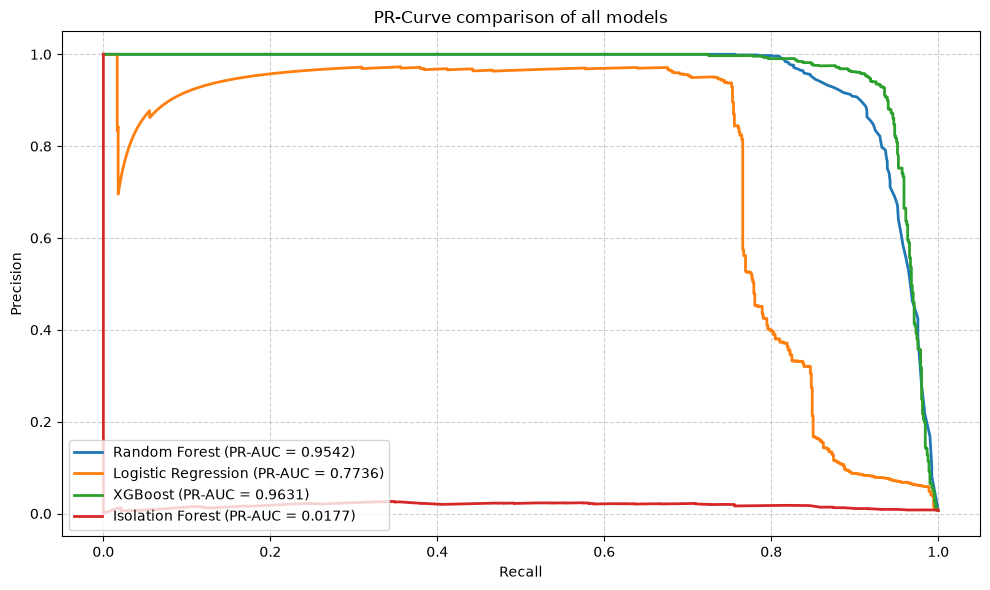

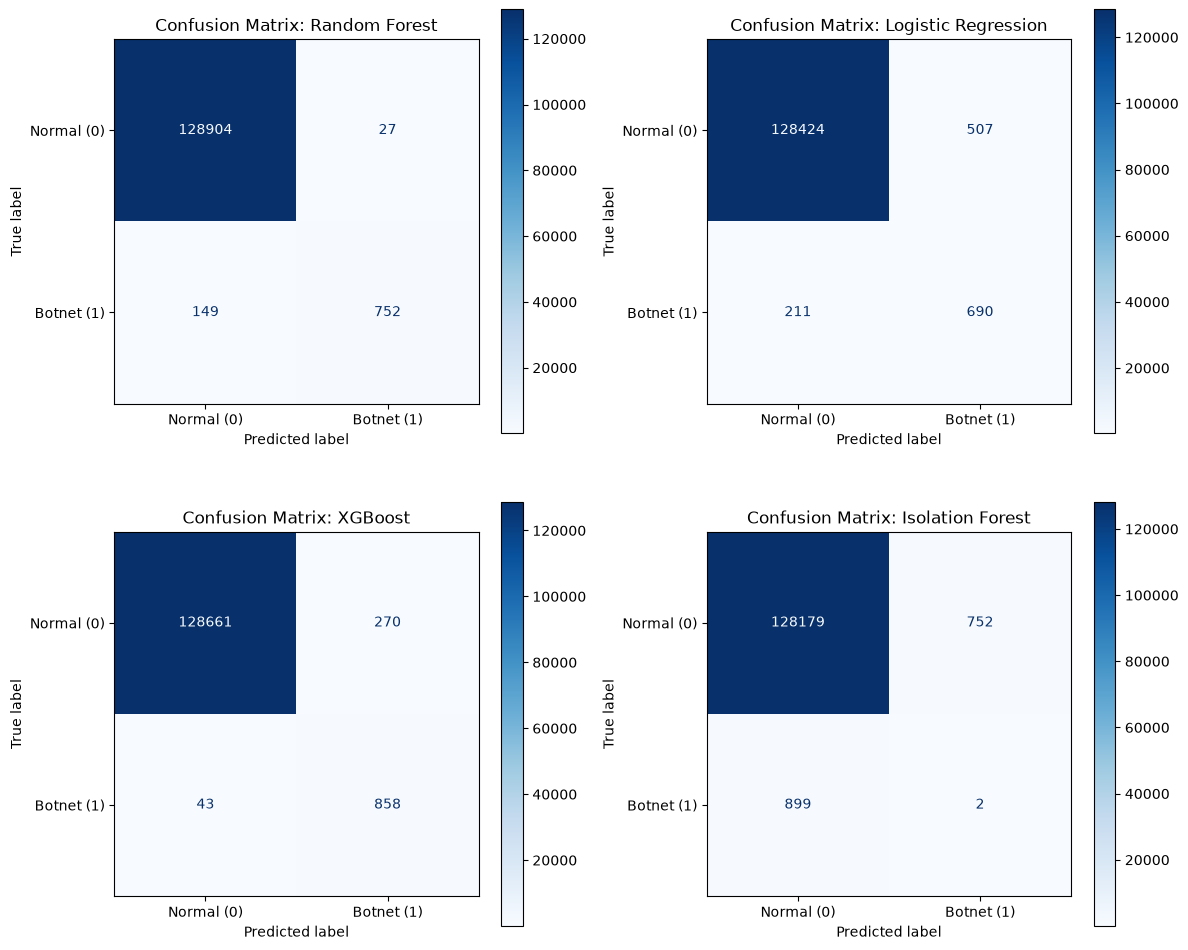

In [117]:
models = {
    'Random Forest': rf_pipeline,
    'Logistic Regression': lr_pipeline,
    'XGBoost': xgb_pipeline,
    'Isolation Forest': iso_forest_pipeline,
}

#5-fold stratified cross-validation, shuffle=True to randomize data order
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []
#dict to save predictions for confusion matrix
y_predicted_dict = {}

plt.figure(figsize=(10, 6))

for name, pipeline in models.items():
  print(f"Evaluation in progress for {name}...")

  if name == 'Isolation Forest':
    #create empty arrays for scores and predictions
    scores = np.zeros(len(X))
    y_predicted = np.zeros(len(X))

    #split data into train and test sets for each fold
    for train_idx, test_idx in skf.split(X, y):
      #allocation of train and test sets data into variables
      X_train = X.iloc[train_idx]
      X_test = X.iloc[test_idx]

      #clone new pipeline to avoid data leakage
      fold_pipe = clone(pipeline)
      
      #training
      fold_pipe.fit(X_train)

      #predictions: 1 Normale, -1 Botnet
      raw_predictions = fold_pipe.predict(X_test)
      y_predicted[test_idx] = np.where(raw_predictions == -1, 1, 0)

      #decision function: more negative values = more anomalous
      scores[test_idx] = fold_pipe.decision_function(X_test)

    #invert sign for PR curve, higher value = more anomalous
    y_probability = -scores

  else:
    y_predicted = cross_val_predict(pipeline, X, y, cv=skf, method='predict', n_jobs=-1)
    #botnet probability
    y_probability = cross_val_predict(pipeline, X, y, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

  #save predictions for confusion matrix
  y_predicted_dict[name] = y_predicted

  #metric calculation
  precision = precision_score(y, y_predicted, pos_label=1, zero_division=0)
  recall = recall_score(y, y_predicted, pos_label=1, zero_division=0)
  f1 = f1_score(y, y_predicted, pos_label=1, zero_division=0)

  precision_curve, recall_curve, threshold = precision_recall_curve(y, y_probability)
  pr_auc = auc(recall_curve, precision_curve)

  results_list.append({
      'Model': name,
      'Precision (Botnet)': round(precision, 4),
      'Recall (Botnet)': round(recall, 4),
      'F1-Score (Botnet)': round(f1, 4),
      'PR-AUC': round(pr_auc, 4),
  })

  #PR-Curve
  plt.plot(
      recall_curve,
      precision_curve,
      lw=2,
      label=f'{name} (PR-AUC = {pr_auc:.4f})',
  )

#comparative table
df_results = pd.DataFrame(results_list).sort_values(by='PR-AUC', ascending=False)

print('\n================ COMPARATIVE PERFORMANCE TABLE ================')
print(df_results.to_string(index=False))
print('=======================================================================\n')

#PR-Curve output
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-Curve comparison of all models')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
#set layout to avoid overlapping
plt.tight_layout()
plt.show()

#output confusion matrix
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for i, (name, y_predicted) in enumerate (y_predicted_dict.items()):
  cm = confusion_matrix(y, y_predicted)
  display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Botnet (1)'])
  display.plot(ax=axes[i], cmap='Blues', values_format='d')
  axes[i].set_title(f'Confusion Matrix: {name}')

#set layout to avoid overlapping
plt.tight_layout()
plt.show()